In [29]:
import pandas as pd
df = pd.read_csv("data_set.csv")
df.head()


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [30]:
df.drop(['TWF', 'HDF', 'PWF', 'OSF', 'RNF'], axis=1, inplace=True)

In [31]:
df.drop(['UDI', 'Product ID'], axis=1, inplace=True)
df = pd.get_dummies(df, columns=['Type'], drop_first=True)
df.isnull().sum()

Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
Type_L                     0
Type_M                     0
dtype: int64

In [32]:

df['temp_diff'] = df['Process temperature [K]'] - df['Air temperature [K]']

df['power'] = df['Torque [Nm]'] * df['Rotational speed [rpm]']

df.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Type_L,Type_M,temp_diff,power
0,298.1,308.6,1551,42.8,0,0,False,True,10.5,66382.8
1,298.2,308.7,1408,46.3,3,0,True,False,10.5,65190.4
2,298.1,308.5,1498,49.4,5,0,True,False,10.4,74001.2
3,298.2,308.6,1433,39.5,7,0,True,False,10.4,56603.5
4,298.2,308.7,1408,40.0,9,0,True,False,10.5,56320.0


In [33]:
X = df.drop('Machine failure', axis=1)
y = df['Machine failure']

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [35]:
df['power'] = df['Torque [Nm]'] * df['Rotational speed [rpm]']
df['temp_diff'] = df['Process temperature [K]'] - df['Air temperature [K]']

In [36]:
print(X_train.shape)
print(X_test.shape)

(8000, 9)
(2000, 9)


In [37]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [38]:
print(X.columns)

Index(['Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Type_L',
       'Type_M', 'temp_diff', 'power'],
      dtype='object')


In [39]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(max_iter=2000)
model_lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


In [40]:
from sklearn.tree import DecisionTreeClassifier

model_dt = DecisionTreeClassifier()
model_dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [41]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier()
model_rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [42]:
from xgboost import XGBClassifier

model_xgb = XGBClassifier()
model_xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [43]:
from sklearn.metrics import accuracy_score

y_pred = model_xgb.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred))

XGBoost Accuracy: 0.99


In [44]:
from sklearn.ensemble import GradientBoostingClassifier

model_gb = GradientBoostingClassifier()
model_gb.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [45]:
from sklearn.metrics import accuracy_score

models = {
    "Logistic": model_lr,
    "Decision Tree": model_dt,
    "Random Forest": model_rf,
    "XGBoost": model_xgb,
    "Gradient Boosting": model_gb
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    print(name, "Accuracy:", accuracy_score(y_test, y_pred))

Logistic Accuracy: 0.9735
Decision Tree Accuracy: 0.981
Random Forest Accuracy: 0.991
XGBoost Accuracy: 0.99
Gradient Boosting Accuracy: 0.9895


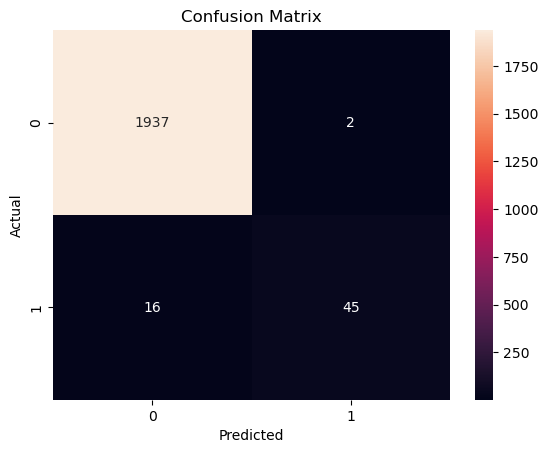

In [46]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, model_rf.predict(X_test))

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

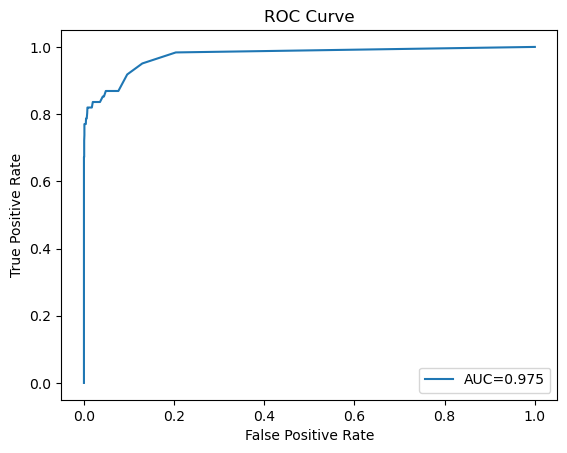

In [47]:
from sklearn.metrics import roc_curve, auc

y_prob = model_rf.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC="+str(round(roc_auc,3)))
plt.legend()
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

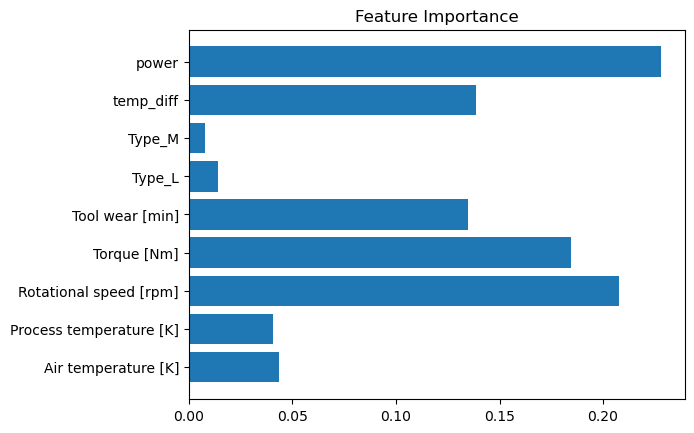

In [48]:
importances = model_rf.feature_importances_

plt.barh(X.columns, importances)
plt.title("Feature Importance")
plt.show()

In [49]:
risk_score = model_rf.predict_proba(X_test)[:,1]

def risk_category(score):
    if score < 0.3:
        return "Low"
    elif score < 0.7:
        return "Medium"
    else:
        return "High"

risk_levels = [risk_category(s) for s in risk_score]

print(risk_levels[:10])

['Low', 'Low', 'Low', 'Low', 'Low', 'Medium', 'Low', 'Low', 'Low', 'Low']


In [50]:
import joblib

joblib.dump(model_rf, "model.pkl")

['model.pkl']

In [51]:
import joblib

joblib.dump(model_rf, "model.pkl")
joblib.dump(scaler, "scaler.pkl")   # if used

['scaler.pkl']